In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('Online Retail (1).xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df=df.dropna(subset=['CustomerID'])

In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5225)

In [9]:
df=df.drop_duplicates(keep='first')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401604.000000,401604,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,250.283037,NaN,69.764035,1714.006089


In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

C:\Users\hai\AppData\Local\Temp\ipykernel_20696\1825311783.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  sns.countplot(data=df,y='Description',order=pd.value_counts(df['Description']).iloc[:20].index,color='#FFB07C',edgecolor='black')


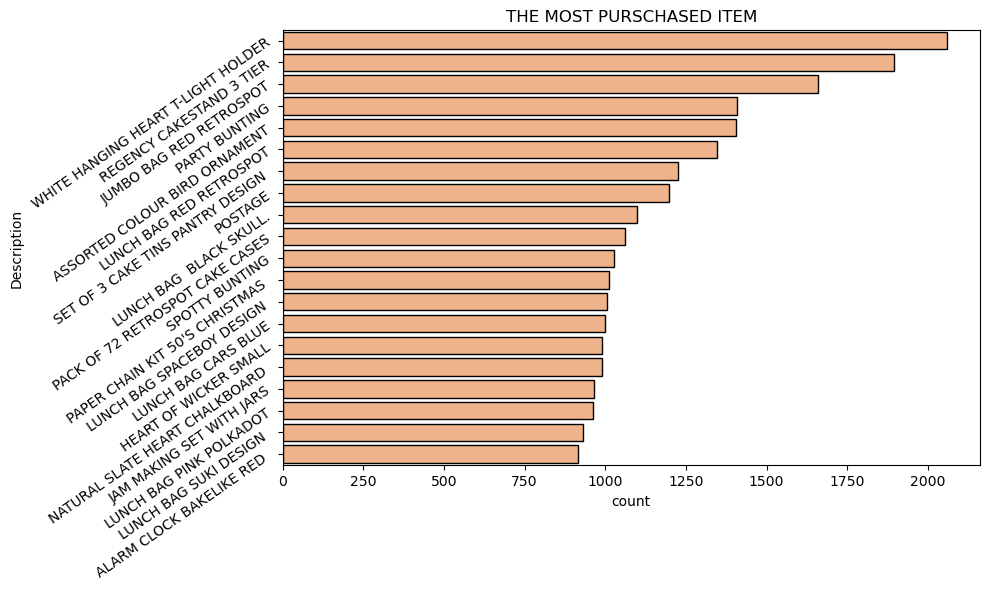

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='Description',order=pd.value_counts(df['Description']).iloc[:20].index,color='#FFB07C',edgecolor='black')
plt.title('THE MOST PURSCHASED ITEM')
plt.yticks(rotation=35)
plt.tight_layout()
plt.show()

C:\Users\hai\AppData\Local\Temp\ipykernel_20696\1978504875.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  sns.countplot(data=df,y='CustomerID',order=pd.value_counts(df['CustomerID']).iloc[:20].index,color='pink',edgecolor='black')


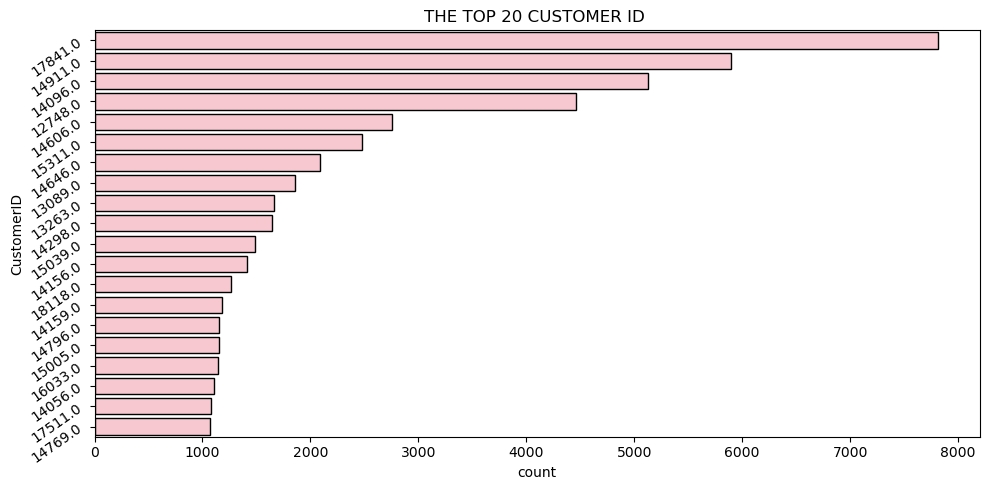

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,y='CustomerID',order=pd.value_counts(df['CustomerID']).iloc[:20].index,color='pink',edgecolor='black')
plt.title('THE TOP 20 CUSTOMER ID ')
plt.yticks(rotation=35)
plt.tight_layout()
plt.show()

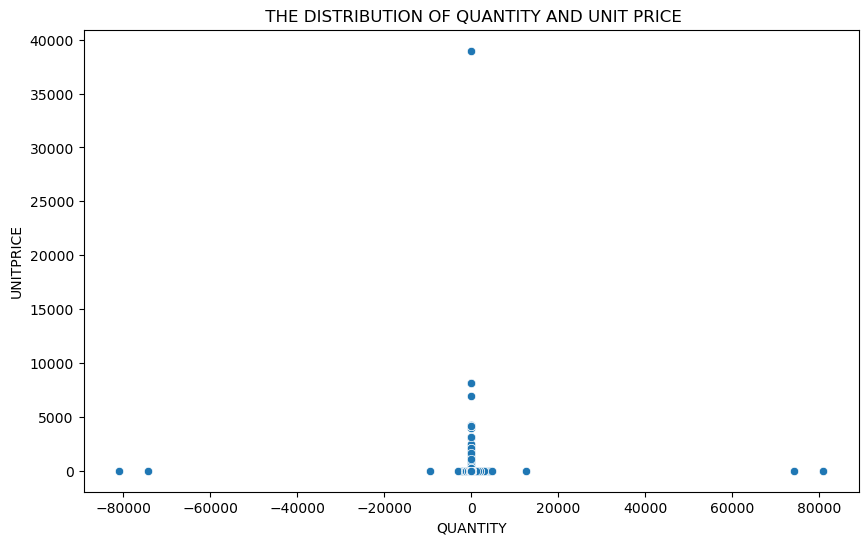

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Quantity',y='UnitPrice')
plt.title(' THE DISTRIBUTION OF QUANTITY AND UNIT PRICE')
plt.xlabel('QUANTITY')
plt.ylabel('UNITPRICE')
plt.show()

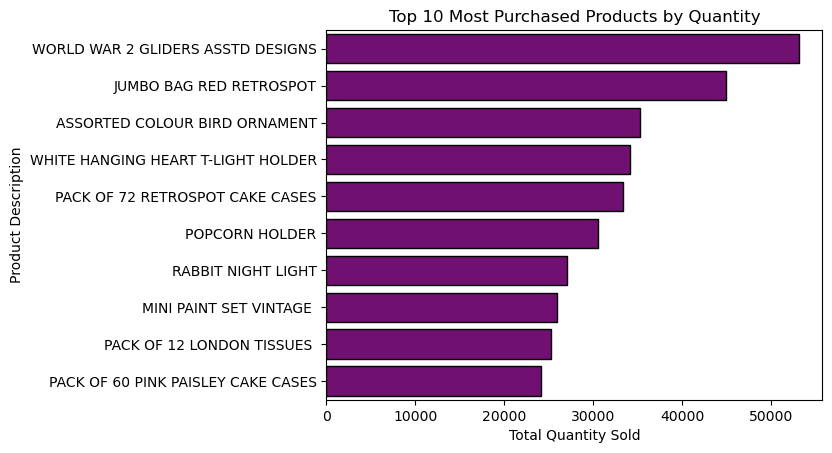

In [16]:
top_products = df.groupby('Description')['Quantity'].sum() \
                 .sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index,color='purple',edgecolor='black')

plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")
plt.title("Top 10 Most Purchased Products by Quantity")
plt.show()

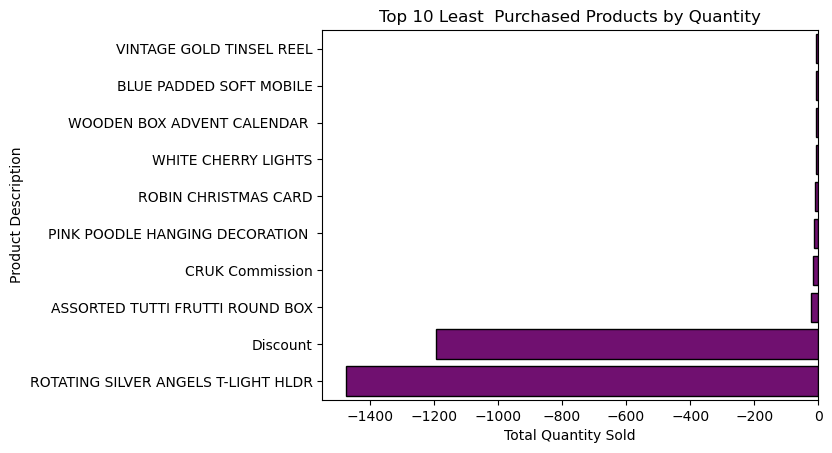

In [17]:
top_products = df.groupby('Description')['Quantity'].sum() \
                 .sort_values(ascending=False).tail(10)

sns.barplot(x=top_products.values, y=top_products.index,color='purple',edgecolor='black')

plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")
plt.title("Top 10 Least  Purchased Products by Quantity")
plt.show()

In [18]:
customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
frequent_customers = customer_frequency[
    customer_frequency >=200
].index
frequent_data = df[
    df['CustomerID'].isin(frequent_customers)
]
product_frequency = frequent_data.groupby('Description')['InvoiceNo'].nunique()
product_frequency = product_frequency.sort_values(
    ascending=False
)

product_frequency.head(10)

Description
CARRIAGE                              85
REGENCY CAKESTAND 3 TIER              62
WHITE HANGING HEART T-LIGHT HOLDER    41
ROSES REGENCY TEACUP AND SAUCER       40
POPCORN HOLDER                        39
GREEN REGENCY TEACUP AND SAUCER       36
VINTAGE SNAP CARDS                    35
SET OF 3 REGENCY CAKE TINS            33
REX CASH+CARRY JUMBO SHOPPER          32
PINK REGENCY TEACUP AND SAUCER        32
Name: InvoiceNo, dtype: int64

In [19]:
def get_month(x):return dt.datetime(x.year,x.month,1)
df['INVOICE_MONTH']=df['InvoiceDate'].apply(get_month)
grouping =df.groupby('CustomerID')['INVOICE_MONTH']
df['COHORT_MONTH']=grouping.transform('min')
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,INVOICE_MONTH,COHORT_MONTH
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-01,2011-08-01
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-01,2011-08-01
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2011-12-01,2011-08-01


In [20]:
def get_month_int(dframe, column):
    year = dframe[column].dt.year
    month = dframe[column].dt.month
    return year, month

invoice_year, invoice_month = get_month_int(df, 'INVOICE_MONTH')
cohort_year, cohort_month = get_month_int(df, 'COHORT_MONTH')

year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

df['COHORT_INDEX'] = year_diff * 12 + month_diff + 1

In [21]:
grouping =df.groupby(['COHORT_MONTH','COHORT_INDEX'])
cohort_data=grouping['CustomerID'].apply(pd.Series.nunique)
cohort_data=cohort_data.reset_index()
cohort_counts=cohort_data.pivot(index='COHORT_MONTH',columns='COHORT_INDEX',values='CustomerID')
cohort_counts

COHORT_INDEX,1,2,3,4,5,6,7,8,9,10,11,12,13
COHORT_MONTH,,,,,,,,,,,,,
2010-12-01,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02-01,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03-01,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04-01,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05-01,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
cohort_size=cohort_counts.iloc[:,0]
retention=cohort_counts.divide(cohort_size,axis=0)
retention.round(3)*100

COHORT_INDEX,1,2,3,4,5,6,7,8,9,10,11,12,13
COHORT_MONTH,,,,,,,,,,,,,
2010-12-01,100.0,38.2,33.4,38.7,36.0,39.7,38.0,35.4,35.4,39.5,37.3,50.0,27.4
2011-01-01,100.0,24.0,28.3,24.2,32.8,29.9,26.1,25.7,31.1,34.7,36.8,15.0,NaN
2011-02-01,100.0,24.7,19.2,27.9,26.8,24.7,25.5,28.2,25.8,31.3,9.2,NaN,NaN
2011-03-01,100.0,19.1,25.5,21.8,23.2,17.7,26.4,23.9,28.9,8.9,NaN,NaN,NaN
2011-04-01,100.0,22.7,22.1,21.1,20.7,23.7,23.1,26.1,8.4,NaN,NaN,NaN,NaN
2011-05-01,100.0,23.7,17.2,17.2,21.5,24.4,26.5,10.4,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,20.9,18.7,27.2,24.7,33.6,10.2,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,20.9,20.4,23.0,27.2,11.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,25.1,25.1,25.1,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


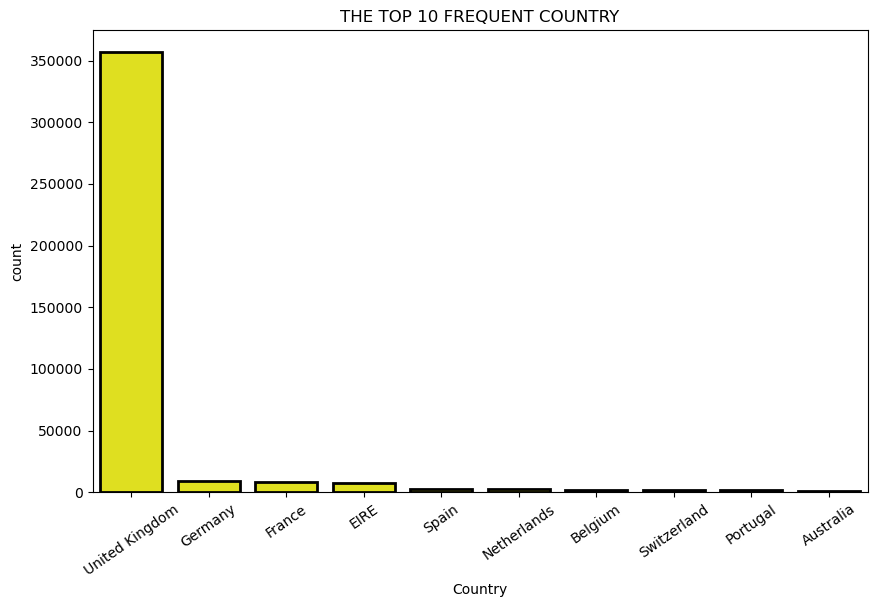

In [23]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Country',order=pd.value_counts(df['Country']).iloc[:10].index,color='yellow',edgecolor='black',linewidth=2)
plt.title('THE TOP 10 FREQUENT COUNTRY')
plt.xticks(rotation=35)

plt.show()

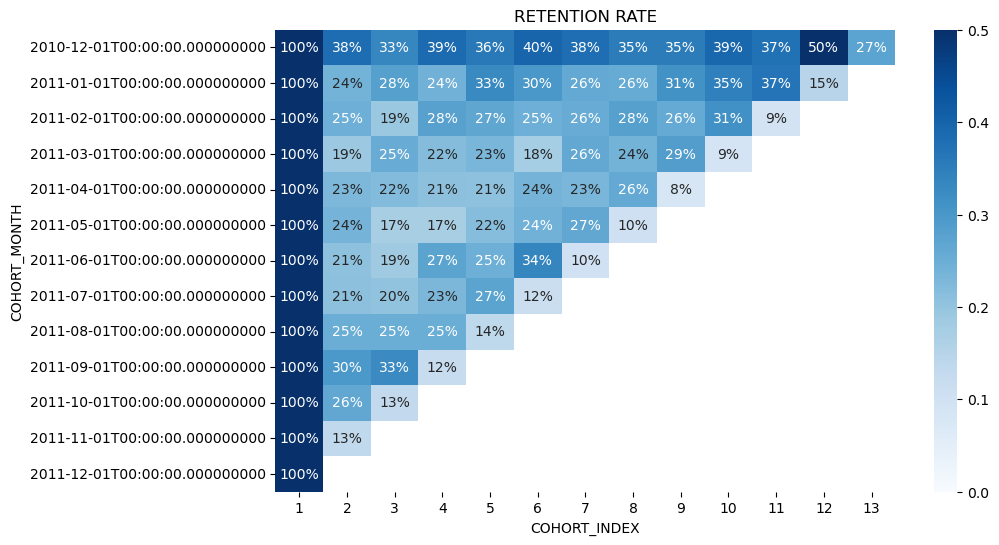

In [24]:
plt.figure(figsize=(10,6))
plt.title("RETENTION RATE")
sns.heatmap(data=retention,annot=True,fmt='.0%',vmin=0.0,vmax=0.5,cmap='Blues')
plt.show()

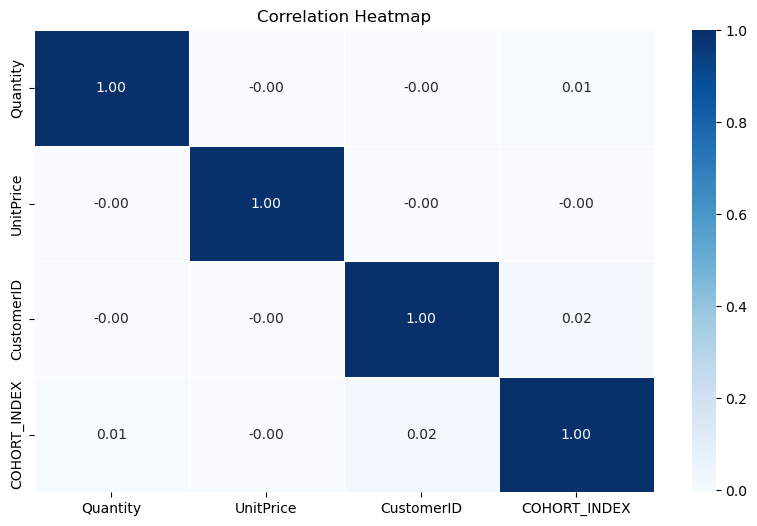

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='Blues',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

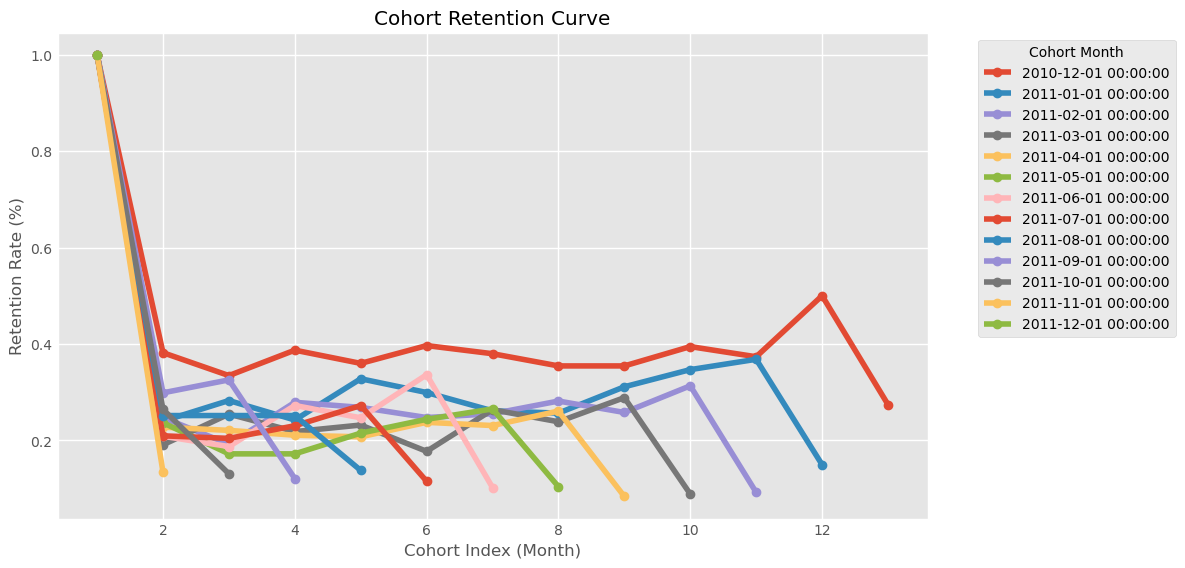

In [67]:
plt.figure(figsize=(10, 6))

for cohort in retention.index:
    plt.plot(
        retention.columns,
        retention.loc[cohort],
        marker='o',
        label=str(cohort)
    )

plt.xlabel('Cohort Index (Month)')
plt.ylabel('Retention Rate (%)')
plt.title('Cohort Retention Curve')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

In [26]:
df['TotalSum']=df['UnitPrice']*df['Quantity']
print('Min Invoice Date :',df.InvoiceDate.dt.date.min(),'max Invoice Date:',df.InvoiceDate.dt.date.max())
df.head(5)

Min Invoice Date : 2010-12-01 max Invoice Date: 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,INVOICE_MONTH,COHORT_MONTH,COHORT_INDEX,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,2010-12-01,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,20.34


In [27]:
snapshot_date=df['InvoiceDate'].max()+dt.timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [28]:
rfm = df.groupby(['CustomerID']).agg({'InvoiceDate': lambda x : (snapshot_date - x.max()).days,
                                      'InvoiceNo':'count','TotalSum': 'sum'})
rfm.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalSum':'MonetaryValue'}
           ,inplace= True)
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [29]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['MonetaryValue'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,5,5,5
12348.0,75,31,1797.24,2,3,4
12349.0,19,73,1757.55,4,4,4
12350.0,310,17,334.40,1,2,2


In [30]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

rfm.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,3
12347.0,2,182,4310.00,5,5,5,15
12348.0,75,31,1797.24,2,3,4,9
12349.0,19,73,1757.55,4,4,4,12
12350.0,310,17,334.40,1,2,2,5


In [31]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Customer_Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,1,1,3,Lost Customers
12347.0,2,182,4310.00,5,5,5,15,Champions
12348.0,75,31,1797.24,2,3,4,9,Potential Loyalists
12349.0,19,73,1757.55,4,4,4,12,Loyal Customers
12350.0,310,17,334.40,1,2,2,5,At Risk


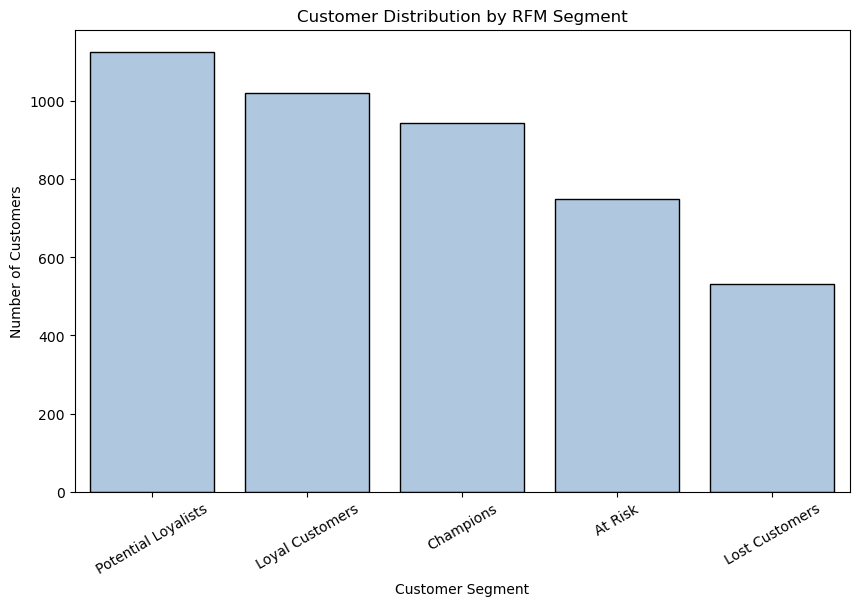

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Customer_Segment',
    color='#A7C7E7',
    edgecolor='black',
    order=rfm['Customer_Segment'].value_counts().index
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)

plt.show()

In [33]:
segment_summary = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

segment_summary

,Recency,Frequency,MonetaryValue
Customer_Segment,,,
At Risk,154.76,18.25,305.35
Champions,14.02,271.57,6197.07
Lost Customers,245.75,8.63,127.22
Loyal Customers,44.57,84.35,1369.82
Potential Loyalists,86.22,36.33,651.92


In [34]:
X = rfm[['Recency', 'Frequency', 'MonetaryValue']]

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [36]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

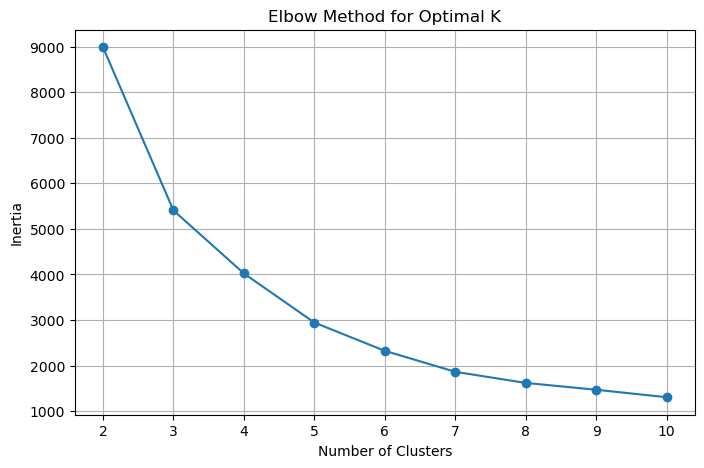

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [38]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Cluster
CustomerID,,,,,,,,,
12346.0,326,2,0.00,1,1,1,3,Lost Customers,1
12347.0,2,182,4310.00,5,5,5,15,Champions,0
12348.0,75,31,1797.24,2,3,4,9,Potential Loyalists,0
12349.0,19,73,1757.55,4,4,4,12,Loyal Customers,0
12350.0,310,17,334.40,1,2,2,5,At Risk,1


In [39]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3045
1    1070
2       4
3       5
4     248
Name: count, dtype: int64

In [40]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,MonetaryValue
Cluster,,,
0,43.37,73.13,1282.13
1,249.78,27.31,465.16
2,2.00,5824.25,64463.56
3,9.00,1012.20,192037.94
4,12.30,489.29,10720.44


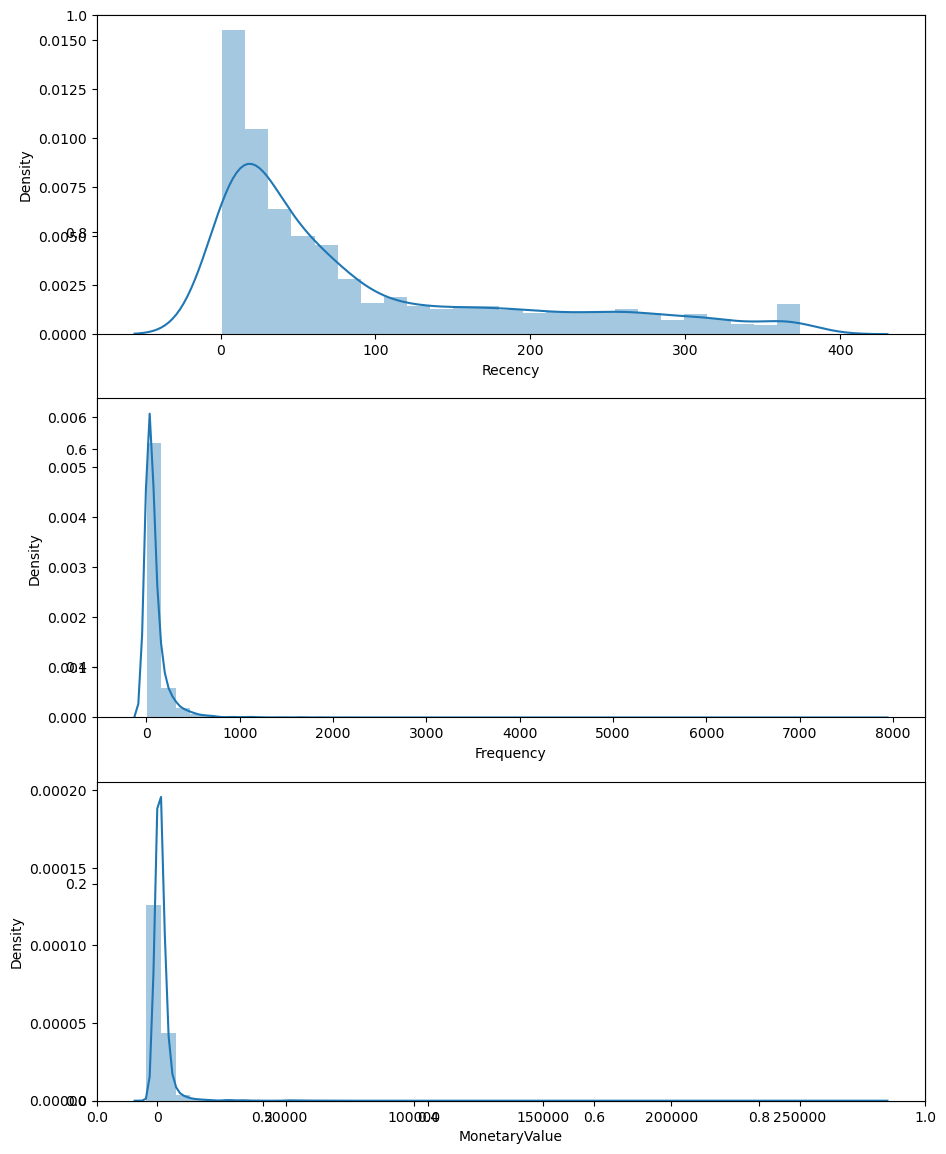

In [41]:
f,ax = plt.subplots(figsize=(10, 12))
plt.subplot(3, 1, 1); sns.distplot(rfm.Recency, label = 'Recency')
plt.subplot(3, 1, 2); sns.distplot(rfm.Frequency, label = 'Frequency')
plt.subplot(3, 1, 3); sns.distplot(rfm.MonetaryValue, label = 'Monetary Value')
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()

In [42]:
rfm_log = rfm[['Recency', 'Frequency', 'MonetaryValue']].apply(np.log1p, axis = 1).round(3)




In [48]:
rfm_log.shape

(4372, 3)

In [49]:
rfm.shape

(4372, 9)

In [50]:
rfm.isnull().sum()

Recency             0
Frequency           0
MonetaryValue       0
R_Score             0
F_Score             0
M_Score             0
RFM_Score           0
Customer_Segment    0
Cluster             0
dtype: int64

In [51]:
rfm_log.isnull().sum()

Recency          0
Frequency        0
MonetaryValue    0
dtype: int64

In [47]:
rfm_log['MonetaryValue'] = rfm_log['MonetaryValue'].fillna(
    rfm_log['MonetaryValue'].median()
)

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm_log)

print(rfm_normalized.shape)

(4372, 3)


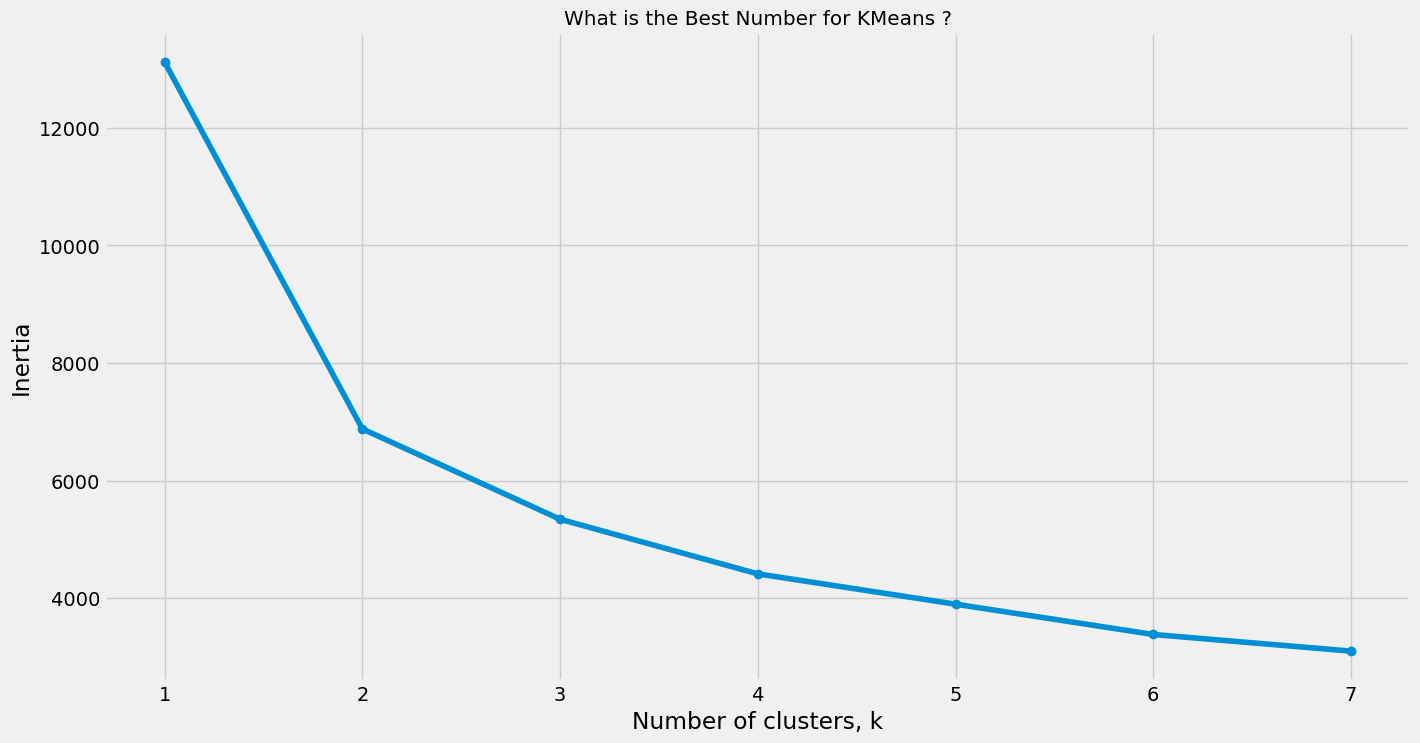

In [54]:
from sklearn.cluster import KMeans
ks = range(1,8)
inertias=[]
for k in ks :
    kc = KMeans(n_clusters=k,random_state=1)
    kc.fit(rfm_normalized)
    inertias.append(kc.inertia_)
f, ax = plt.subplots(figsize=(15, 8))
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.style.use('ggplot')
plt.title('What is the Best Number for KMeans ?')
plt.show()

In [55]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_normalized)

In [56]:
len(clusters)

4372

In [57]:
rfm['Cluster'] = clusters

In [58]:
rfm.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Cluster
CustomerID,,,,,,,,,
12346.0,326,2,0.00,1,1,1,3,Lost Customers,0
12347.0,2,182,4310.00,5,5,5,15,Champions,1
12348.0,75,31,1797.24,2,3,4,9,Potential Loyalists,2
12349.0,19,73,1757.55,4,4,4,12,Loyal Customers,2
12350.0,310,17,334.40,1,2,2,5,At Risk,0


In [59]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    1545
1     984
2    1843
Name: count, dtype: int64

In [60]:
cluster_summary = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'MonetaryValue']
].mean()

cluster_summary

,Recency,Frequency,MonetaryValue
Cluster,,,
0,176.460841,15.519094,269.447133
1,13.128049,264.007114,6048.027530
2,63.418340,63.941400,1036.877110


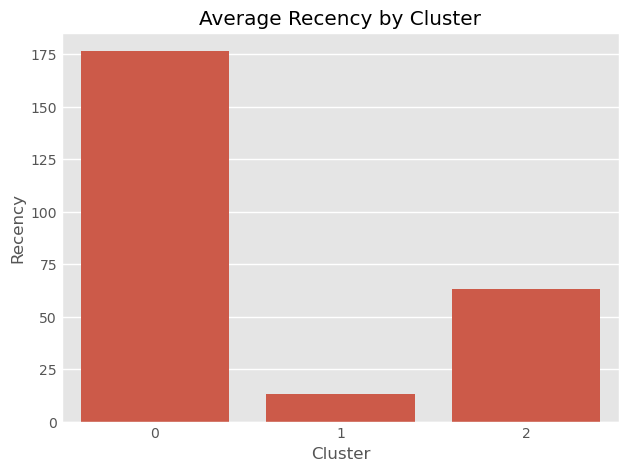

In [61]:
sns.barplot(
    data=rfm,
    x='Cluster',
    y='Recency',
    errorbar=None
)

plt.title('Average Recency by Cluster')
plt.show()

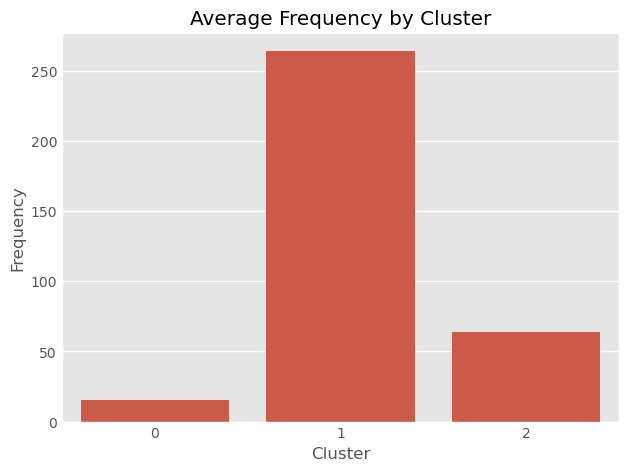

In [62]:
sns.barplot(
    data=rfm,
    x='Cluster',
    y='Frequency',
    errorbar=None
)

plt.title('Average Frequency by Cluster')
plt.show()

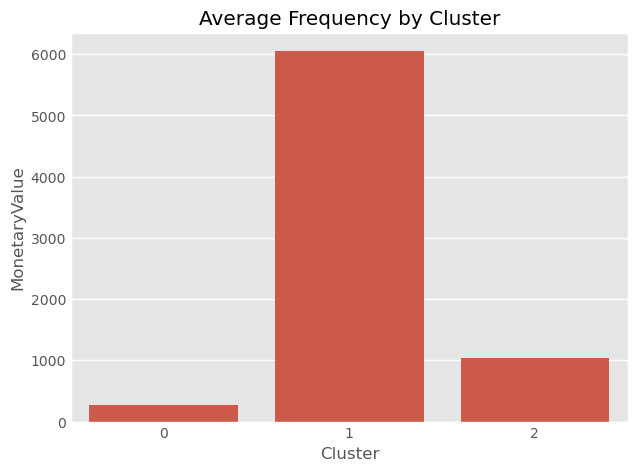

In [63]:
sns.barplot(
    data=rfm,
    x='Cluster',
    y='MonetaryValue',
    errorbar=None
)

plt.title('Average MonetaryValue by Cluster')
plt.show()

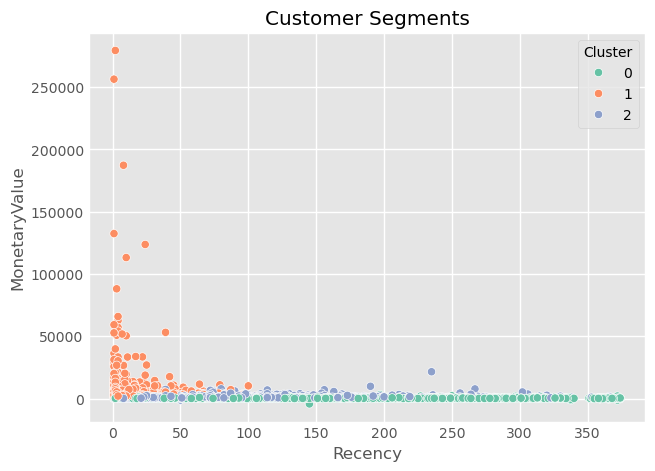

In [65]:
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='MonetaryValue',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments')
plt.show()

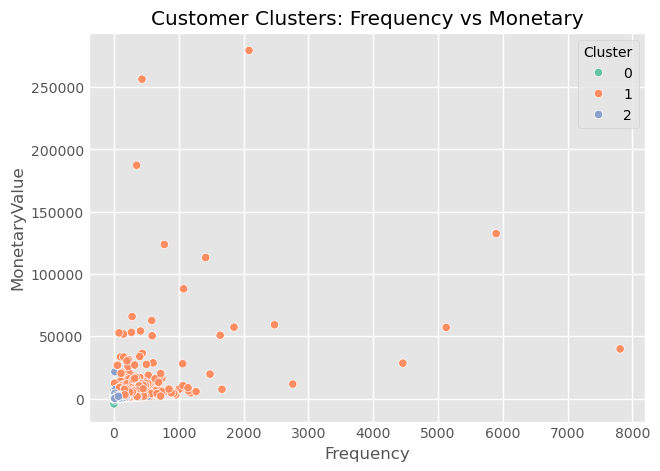

In [66]:
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='MonetaryValue',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Clusters: Frequency vs Monetary')
plt.show()